# 04. Focal (Neighborhood) Statistics
Apply moving-window operations like Median, Mean, and Standard Deviation filters directly on the GPU.

In [1]:
import curaster
import matplotlib.pyplot as plt
import os

input_file = "../build/benchmark_data/test_S_2048x2048.tif"

## Apply Focal Median Filter
We will extract Band 1, apply a focal median filter with a radius of 3 (7x7 window), and compare it to the original.

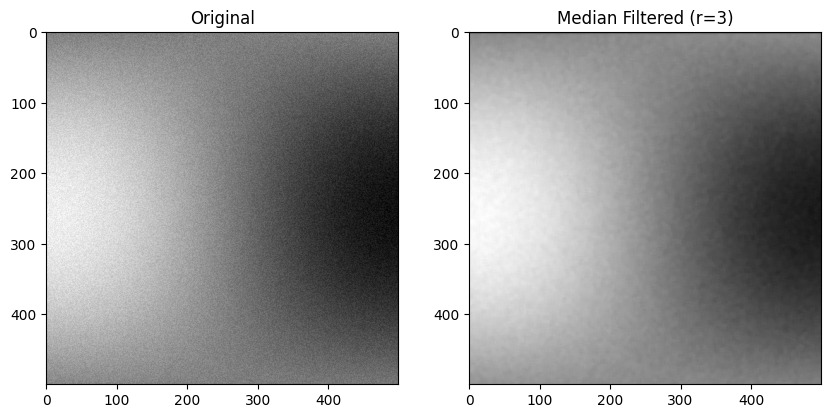

CPU times: user 887 ms, sys: 335 ms, total: 1.22 s
Wall time: 1.09 s


In [2]:
%%time
# Original Band 1
original = curaster.open(input_file).algebra("B1").to_memory().data()

# Median Filter
median_chain = curaster.open(input_file) \
    .algebra("B1") \
    .focal("median", radius=3, shape="square")

filtered = median_chain.to_memory().data()

# Plot
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(original[:500, :500], cmap="gray"); axes[0].set_title("Original")
axes[1].imshow(filtered[:500, :500], cmap="gray"); axes[1].set_title("Median Filtered (r=3)")
plt.show()

In [3]:
type(filtered)

numpy.ndarray

In [4]:
filtered.min(), filtered.max()

(np.float32(7.6875), np.float32(7721.3945))